In [23]:
import numpy as np

(400, 64)

In [28]:
h.dtype

dtype('complex64')

(3546, 64)
Occupied subcarriers: [-26, -25, -24, -23, -22, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26]
Occupied subcarrier indexes: [ 6  7  8  9 10 12 13 14 15 16 17 18 19 20 21 22 23 24 26 27 28 29 30 31
 33 34 35 36 37 38 40 41 42 43 44 45 46 47 48 49 50 51 52 54 55 56 57 58]


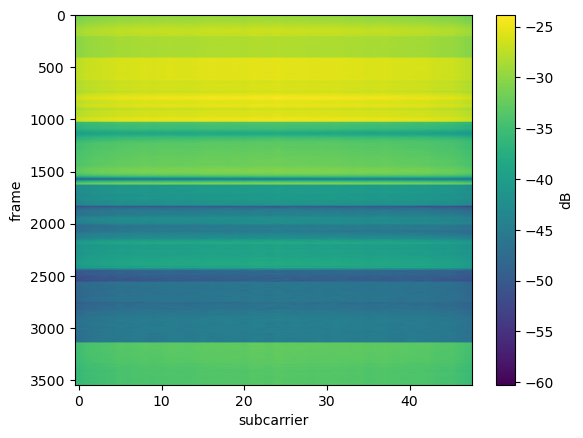

In [119]:
h = np.load("/tmp/h_dataset.npy") 
n_subcarriers = h.shape[1]         # (N, 64) complex
print(h.shape)

# look at how |h| evolves over frames
import matplotlib.pyplot as plt

occupied_subcarriers = list(range(-26,-21)) + list(range(-20,-7)) + list(range(-6,0)) + list(range(1,7)) + list(range(8,21)) + list(range(22,27))
occupied_subcarriers_indexes = np.array(occupied_subcarriers) + n_subcarriers//2
print("Occupied subcarriers:", occupied_subcarriers)
print("Occupied subcarrier indexes:", occupied_subcarriers_indexes)

plt.imshow(20*np.log10(np.abs(h[:, occupied_subcarriers_indexes]) + 1e-9), aspect='auto')
plt.xlabel('subcarrier'); plt.ylabel('frame'); plt.colorbar(label='dB')
plt.show()

Estimated SNR per frame: [0.00095054 0.00096118 0.00098209 ... 0.00038571 0.00038131 0.00038459]


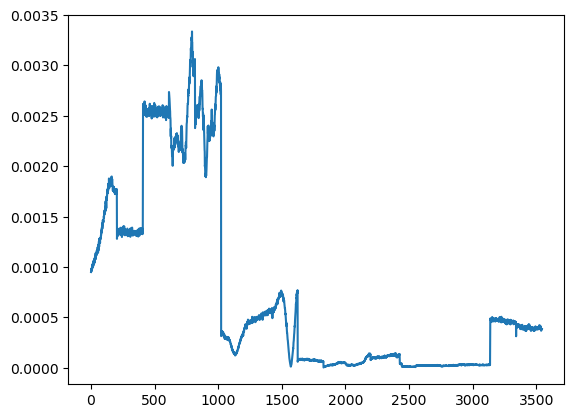

In [128]:
pilot_subcarriers = [-21, -7, 7, 21]
pilot_subcarriers_indexes = np.array(pilot_subcarriers) + n_subcarriers//2
pilots_symbols = [1, 1, 1, -1]
pilots_symbols_eq = pilots_symbols / np.abs(h[:, pilot_subcarriers_indexes])
noise_power_estimate = np.mean(np.abs(pilots_symbols_eq - h[:, pilot_subcarriers_indexes])**2, axis=1)
SNR = 1 / noise_power_estimate
print("Estimated SNR per frame:", SNR)
plt.plot(SNR)

In [100]:
h[0,:]

array([ 0.        +0.j        ,  0.        +0.j        ,
        0.        +0.j        ,  0.        +0.j        ,
        0.        +0.j        ,  0.        +0.j        ,
       -0.01969074+0.02234484j, -0.00098064+0.03002578j,
        0.01792524+0.02325795j,  0.02467017+0.0060831j ,
        0.03098707-0.01307285j,  0.01133479-0.02288477j,
       -0.01177658-0.03187285j, -0.02785601-0.0122055j ,
       -0.0252868 +0.01005435j, -0.02137893+0.02199292j,
        0.00211   +0.03490541j,  0.0256167 +0.01794234j,
        0.03061983-0.00695992j,  0.01831548-0.02751236j,
       -0.00290555-0.03387567j, -0.01947165-0.02472674j,
       -0.0319698 -0.00555668j, -0.02323675+0.01913673j,
       -0.00245658+0.03156867j,  0.01956725+0.02636323j,
        0.0296557 +0.00823077j,  0.03049707-0.00410357j,
        0.02154882-0.03128233j, -0.00400833-0.02947419j,
       -0.02650007-0.02350989j, -0.03296086+0.00211399j,
        0.        +0.j        , -0.00235208+0.02915508j,
        0.0185858 +0.02934464j,

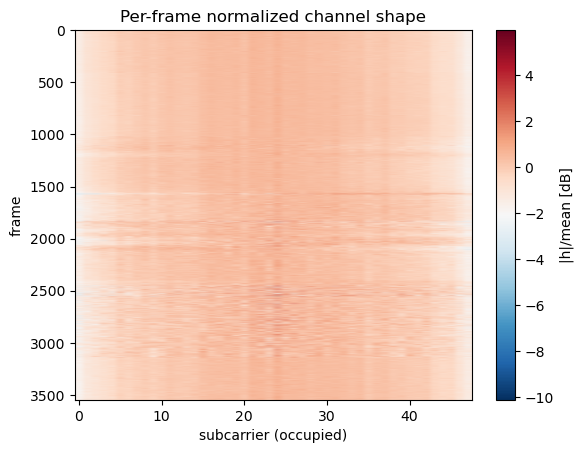

In [118]:
mag = np.abs(h[:, occupied_subcarriers_indexes])
mag_norm = mag / mag.mean(axis=1, keepdims=True)   # divide each frame by its own mean
db = 20*np.log10(mag_norm + 1e-9)
plt.imshow(db, aspect='auto', cmap='RdBu_r')
plt.xlabel('subcarrier (occupied)'); plt.ylabel('frame')
plt.colorbar(label='|h|/mean [dB]')
plt.title('Per-frame normalized channel shape')
plt.show()

In [93]:
np.abs(H)[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.02978283, 0.02936404, 0.02540908, 0.0336318 , 0.02553801,
       0.03397892, 0.03041269, 0.02721235, 0.03067161, 0.03496913,
       0.03127527, 0.03140087, 0.03305127, 0.03400004, 0.03244912,
       0.03010251, 0.03166411, 0.03283135, 0.03077672, 0.03129943,
       0.03816232, 0.03250568, 0.02639056, 0.03509473, 0.03290171,
       0.03245312, 0.02947742, 0.02875289, 0.03303685, 0.03417166,
       0.03039145, 0.02680125, 0.02999876, 0.03073185, 0.02900923,
       0.03134355, 0.02557434, 0.02350504, 0.        , 0.        ,
       0.        , 0.        , 0.        ], dtype=float32)

In [94]:
H[0]

array([ 0.        +0.j        ,  0.        +0.j        ,
        0.        +0.j        ,  0.        +0.j        ,
        0.        +0.j        , -0.01969074+0.02234484j,
        0.01792524+0.02325795j,  0.02467017+0.0060831j ,
        0.03098707-0.01307285j,  0.01133479-0.02288477j,
       -0.01177658-0.03187285j, -0.02785601-0.0122055j ,
       -0.0252868 +0.01005435j, -0.02137893+0.02199292j,
        0.00211   +0.03490541j,  0.0256167 +0.01794234j,
        0.03061983-0.00695992j,  0.01831548-0.02751236j,
       -0.00290555-0.03387567j, -0.0319698 -0.00555668j,
       -0.02323675+0.01913673j, -0.00245658+0.03156867j,
        0.01956725+0.02636323j,  0.0296557 +0.00823077j,
       -0.00707071-0.03049032j, -0.03573255-0.01339953j,
       -0.03008266+0.01231473j, -0.0116302 +0.02368966j,
        0.00312201+0.03495559j,  0.03140859-0.00979911j,
        0.01615731-0.0281451j , -0.00405064-0.02919779j,
       -0.01792904-0.0224784j , -0.03226719-0.00708959j,
       -0.02649939+0.0215751j ,

In [15]:
occ = sorted(set(list(range(-26,-21)) + list(range(-20,-7)) + list(range(-6,0))
                 + list(range(1,7)) + list(range(8,21)) + list(range(22,27))))
occ

[-26,
 -25,
 -24,
 -23,
 -22,
 -20,
 -19,
 -18,
 -17,
 -16,
 -15,
 -14,
 -13,
 -12,
 -11,
 -10,
 -9,
 -8,
 -6,
 -5,
 -4,
 -3,
 -2,
 -1,
 1,
 2,
 3,
 4,
 5,
 6,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 22,
 23,
 24,
 25,
 26]